# 03 – Propriedades Dependentes da Temperatura & Gráficos

Uma capacidade calorífica constante é uma boa aproximação em uma janela estreita
de temperatura, mas combustão, turbinas a gás e escoamentos reativos abrangem
centenas — até milhares — de kelvin. Nesse regime, $C_p$, $S^\circ$ e $H^\circ$
variam fortemente, e o `pyglenn` fornece sua verdadeira dependência com a
temperatura diretamente dos polinômios da NASA.

Neste notebook nós:

1. varremos a temperatura e construímos curvas de propriedades para vários
   gases;
2. lemos a física por trás das curvas $C_p(T)$ (equipartição e vibrações);
3. tabulamos os resultados com `pandas`;
4. contrastamos as capacidades caloríficas *instantânea* e *média*; e
5. vemos como fases condensadas possuem faixas de validade mais estreitas.

In [1]:
from pyglenn import ThermochemicalCalculator, R

print("Universal gas constant R =", R, "J/(mol.K)")


Constante universal dos gases R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. Varrendo a temperatura

`get_properties_range(id, temps)` avalia uma lista inteira de temperaturas de
uma vez e retorna um dicionário indexado por temperatura. Nós o envolvemos em um
pequeno auxiliar que retorna arrays prontos para plotagem, ignorando qualquer
temperatura que esteja fora da faixa de validade da espécie (estas simplesmente
não aparecem).

In [3]:
SPECIES = ["Ar", "H2", "N2", "O2", "H2O", "CO2", "CH4"]

def curve(calc, name, temps):
    """Retorna arrays (T, cp, s, h) para as temperaturas que estão dentro da faixa."""
    sid = calc.get_available_species(name, exact_match=True)[0]["id"]
    table = calc.get_properties_range(sid, list(temps)) or {}
    T = np.array(sorted(table))
    cp = np.array([table[t]["cp"] for t in T])
    s = np.array([table[t]["s"] for t in T])
    h = np.array([table[t]["h_relative"] for t in T])
    return T, cp, s, h

temps = np.linspace(300, 3000, 55)
data = {}
with ThermochemicalCalculator() as calc:
    for name in SPECIES:
        data[name] = curve(calc, name, temps)
print("Curvas calculadas para:", ", ".join(data))

Curvas calculadas para: Ar, H2, N2, O2, H2O, CO2, CH4


## 2. Três curvas de propriedades

$C_p^\circ(T)$, $S^\circ(T)$ e a **entalpia sensível**
$H^\circ(T)-H^\circ(298{,}15\,\mathrm{K})$ (a entalpia necessária para aquecer
a espécie a partir da temperatura ambiente). Subtraímos o valor a 298,15 K para
que cada curva comece próxima de zero e as formas sejam comparáveis,
independentemente da entalpia de formação.

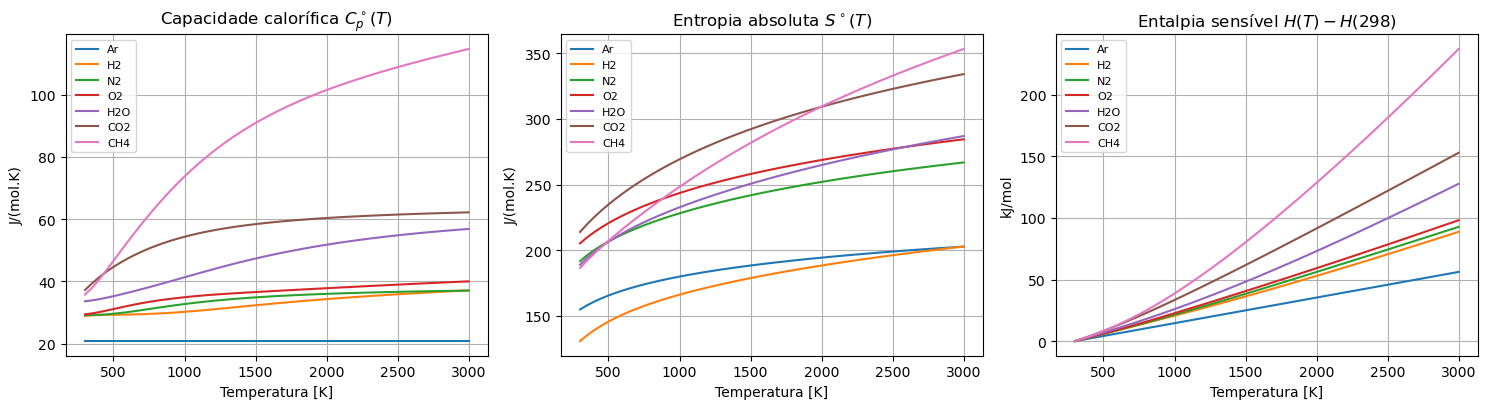

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
with ThermochemicalCalculator() as calc:
    h_ref = {n: calc.calculate_properties(calc.get_available_species(n, exact_match=True)[0]["id"], 298.15)["h_relative"]
             for n in SPECIES}

for name in SPECIES:
    T, cp, s, h = data[name]
    axes[0].plot(T, cp, label=name)
    axes[1].plot(T, s, label=name)
    axes[2].plot(T, (h - h_ref[name]) / 1000.0, label=name)

axes[0].set_title(r"Capacidade calorífica $C_p^\circ(T)$"); axes[0].set_ylabel("J/(mol.K)")
axes[1].set_title(r"Entropia absoluta $S^\circ(T)$"); axes[1].set_ylabel("J/(mol.K)")
axes[2].set_title("Entalpia sensível $H(T)-H(298)$"); axes[2].set_ylabel("kJ/mol")
for ax in axes:
    ax.set_xlabel("Temperatura [K]"); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 3. Lendo a física: equipartição

A capacidade calorífica adimensional $C_p/R$ revela a estrutura molecular. Pela
equipartição, cada grau de liberdade quadrático totalmente ativo contribui com
$\tfrac12 R$ para $C_v$, e para um gás ideal $C_p = C_v + R$:

* **Monoatômico** (Ar): apenas 3 modos translacionais $\Rightarrow C_v=\tfrac32
  R$, logo $C_p=\tfrac52 R$ — constante em todas as temperaturas.
* **Diatômico** (N₂, O₂, H₂): + 2 modos rotacionais $\Rightarrow
  C_p=\tfrac72 R$ em $T$ moderada, subindo ainda mais quando o modo vibracional
  é ativado.
* **Poliatômico** (CO₂, H₂O, CH₄): mais modos rotacionais e muitos modos
  vibracionais, portanto $C_p/R$ é maior e sobe acentuadamente.

As linhas tracejadas marcam os platôs $\tfrac52$ e $\tfrac72$.

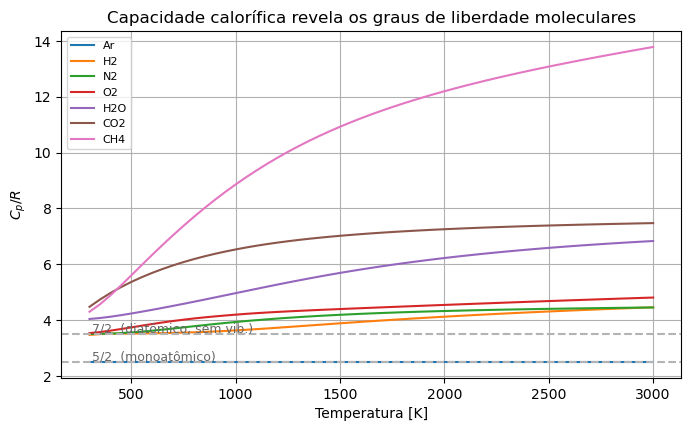

In [5]:
fig, ax = plt.subplots()
for name in SPECIES:
    T, cp, s, h = data[name]
    ax.plot(T, cp / R, label=name)
for level, txt in [(2.5, "5/2  (monoatômico)"), (3.5, "7/2  (diatômico, sem vib.)")]:
    ax.axhline(level, ls="--", color="0.7")
    ax.text(310, level + 0.05, txt, fontsize=9, color="0.4")
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel(r"$C_p / R$")
ax.set_title("Capacidade calorífica revela os graus de liberdade moleculares")
ax.legend(fontsize=8)
plt.show()

## 4. Uma tabela de propriedades com pandas

Tabelas discretas ainda são úteis para relatórios. Aqui está $C_p$ em um
conjunto de temperaturas para cada espécie, ordenado pelo valor a 2000 K para
classificá-las por quanta energia elas absorvem quando aquecidas.

In [6]:
table_temps = [300, 600, 1000, 1500, 2000, 2500]
records = {}
with ThermochemicalCalculator() as calc:
    for name in SPECIES:
        sid = calc.get_available_species(name, exact_match=True)[0]["id"]
        records[name] = {f"{t} K": calc.calculate_properties(sid, t)["cp"]
                         for t in table_temps}

cp_df = pd.DataFrame(records).T.sort_values("2000 K", ascending=False)
cp_df.index.name = "espécie"
print("Cp [J/(mol.K)]")
print(cp_df.to_string())

Cp [J/(mol.K)]
         300 K  600 K  1000 K  1500 K  2000 K  2500 K
espécie                                              
CH4     35.760 52.690  73.676  90.865 101.442 108.789
CO2     37.220 47.322  54.308  58.374  60.334  61.443
H2O     33.596 36.324  41.291  47.318  51.755  54.777
O2      29.387 32.090  34.882  36.553  37.784  38.933
N2      29.125 30.109  32.696  34.842  35.970  36.615
H2      28.849 29.318  30.206  32.304  34.276  35.832
Ar      20.786 20.786  20.786  20.786  20.786  20.786


## 5. Capacidade calorífica instantânea vs. média

Duas capacidades caloríficas aparecem em cálculos de engenharia:

* a **instantânea** $C_p(T) = \left(\partial H/\partial T\right)_p$;
* a **média** $\overline{C_p}\big|_{T_1}^{T_2} = \dfrac{H(T_2)-H(T_1)}{T_2-T_1}$,
  que é o que você de fato multiplica por $\Delta T$ para obter uma variação de
  entalpia.

Usando `calculate_enthalpy_change` para o numerador, comparamos as duas para o
nitrogênio. A média (a partir de 300 K) fica abaixo do valor instantâneo porque
ela incorpora a região mais fria, de menor $C_p$.

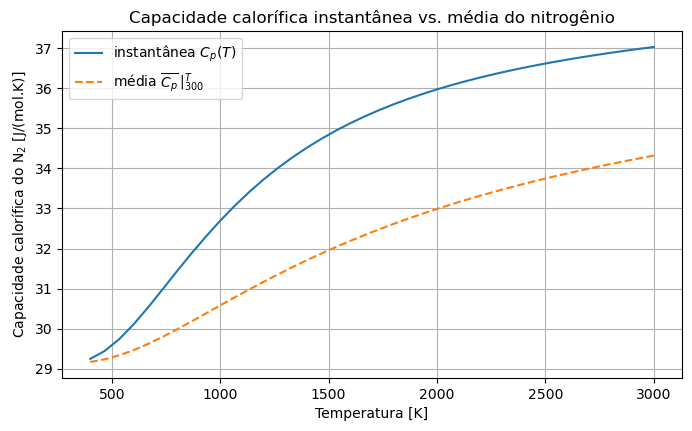

In [7]:
T2 = np.linspace(400, 3000, 40)
with ThermochemicalCalculator() as calc:
    n2 = calc.get_available_species("N2", exact_match=True)[0]["id"]
    cp_inst = np.array([calc.calculate_properties(n2, t)["cp"] for t in T2])
    cp_mean = np.array([calc.calculate_enthalpy_change(n2, 300.0, t) / (t - 300.0)
                        for t in T2])

fig, ax = plt.subplots()
ax.plot(T2, cp_inst, label=r"instantânea $C_p(T)$")
ax.plot(T2, cp_mean, "--", label=r"média $\overline{C_p}\,|_{300}^{T}$")
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel("Capacidade calorífica do N$_2$ [J/(mol.K)]")
ax.set_title("Capacidade calorífica instantânea vs. média do nitrogênio")
ax.legend()
plt.show()

## 6. Fases condensadas têm faixas mais estreitas

Os ajustes para fase gasosa tipicamente cobrem 200–6000 K, mas líquidos e
sólidos são válidos apenas em uma janela pequena. Solicitar uma temperatura fora
dessa janela retorna `None` — sempre trate esse caso. A água líquida é um bom
exemplo.

In [8]:
with ThermochemicalCalculator() as calc:
    liq = calc.get_available_species("H2O(L)", exact_match=True)[0]["id"]
    data_liq = calc.db.get_species_data(liq)
    ranges = [(iv["temp_min"], iv["temp_max"]) for iv in data_liq["intervals"]]
    print("H2O(L) intervalo(s) válido(s):", ranges)
    for T in [350.0, 2000.0]:
        p = calc.calculate_properties(liq, T)
        status = "None (fora da faixa)" if p is None else f"Cp = {p['cp']:.2f} J/(mol.K)"
        print(f"  T = {T:7.1f} K  ->  {status}")

Temperature 2000.0 K out of valid range for species 'H2O(L)'. Available intervals: [(273.15, 373.15), (373.15, 600.0)]


H2O(L) intervalo(s) válido(s): [(273.15, 373.15), (373.15, 600.0)]
  T =   350.0 K  ->  Cp = 75.53 J/(mol.K)
  T =  2000.0 K  ->  None (fora da faixa)


## Resumo

- `get_properties_range` varre muitas temperaturas em uma única chamada.
- A forma de $C_p/R$ reflete diretamente os graus de liberdade translacionais,
  rotacionais e vibracionais.
- $C_p$ média e instantânea são diferentes — use a média (via
  `calculate_enthalpy_change`) para $\Delta T$ finito.
- Sempre trate `None` para temperaturas fora da faixa, especialmente para fases
  condensadas.

**A seguir:** o notebook 04 extrai entalpias de formação desses mesmos
polinômios.